In [1]:
!pip install nsepy yfinance pandas matplotlib seaborn statsmodels

  Preparing metadata (setup.py) ... done
  Created wheel for nsepy: filename=nsepy-0.8-py3-none-any.whl size=36057 sha256=ae513a86f3a911497fef890749683142f26653d1d10e30a78b4139bf2c1d6aab
  Stored in directory: /root/.cache/pip/wheels/ba/d6/a0/a2c830ea2a083f15d9790732c1908625dd6314a02f09a92130
Successfully built nsepy


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

In [3]:
import yfinance as yf
from datetime import datetime, timedelta

end_date = datetime.today()
start_date = end_date - timedelta(days=365)

data = yf.download("COFORGE.NS", start=start_date, end=end_date)

data.head()

/tmp/ipykernel_19726/1653193551.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("COFORGE.NS", start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,COFORGE.NS,COFORGE.NS,COFORGE.NS,COFORGE.NS,COFORGE.NS
Date,,,,,
2025-04-01,1541.687256,1598.979375,1537.565911,1598.979375,2221335
2025-04-02,1537.872925,1552.307364,1516.572884,1541.687094,2470850
2025-04-03,1418.166748,1515.760582,1415.115437,1505.090728,6409960
2025-04-04,1309.288818,1405.574982,1300.025801,1396.955822,11705110
2025-04-07,1256.345947,1271.057814,1182.905373,1183.886156,11740295


In [4]:
data.to_csv("COFORGE_1year.csv")
print("CSV Saved Successfully!")

CSV Saved Successfully!


In [5]:
import os
os.listdir()

['.config', 'COFORGE_1year.csv', 'sample_data']

In [6]:
df = data.reset_index()
df.to_csv("COFORGE_1year.csv", index=False)
print("CSV Saved with Date Column Successfully!")

CSV Saved with Date Column Successfully!


In [7]:
check = pd.read_csv("COFORGE_1year.csv")
check.head()

,Date,Close,High,Low,Open,Volume
0,NaN,COFORGE.NS,COFORGE.NS,COFORGE.NS,COFORGE.NS,COFORGE.NS
1,2025-04-01,1541.687255859375,1598.9793751133031,1537.5659113074669,1598.9793751133031,2221335
2,2025-04-02,1537.8729248046875,1552.3073644900853,1516.5728838107807,1541.6870940049669,2470850
3,2025-04-03,1418.166748046875,1515.76058247384,1415.1154365917382,1505.0907276498608,6409960
4,2025-04-04,1309.288818359375,1405.5749815858362,1300.0258006883546,1396.9558219483756,11705110


In [35]:
df = data.reset_index()
df.to_csv("COFORGE_1year.csv", index=False)

print("COFORGE dataset saved successfully as COFORGE_1year.csv")

COFORGE dataset saved successfully as COFORGE_1year.csv


In [9]:
import pandas as pd

df = pd.read_csv("COFORGE_1year.csv")
df.head()

,Date,Close,High,Low,Open,Volume
0,NaN,COFORGE.NS,COFORGE.NS,COFORGE.NS,COFORGE.NS,COFORGE.NS
1,2025-04-01,1541.687255859375,1598.9793751133031,1537.5659113074669,1598.9793751133031,2221335
2,2025-04-02,1537.8729248046875,1552.3073644900853,1516.5728838107807,1541.6870940049669,2470850
3,2025-04-03,1418.166748046875,1515.76058247384,1415.1154365917382,1505.0907276498608,6409960
4,2025-04-04,1309.288818359375,1405.5749815858362,1300.0258006883546,1396.9558219483756,11705110


In [19]:
print(data.shape)

(248, 5)


In [20]:
print(data.index.min())
print(data.index.max())

2025-04-01 00:00:00
2026-04-01 00:00:00


In [10]:
df['Date'] = pd.to_datetime(df['Date'])

In [11]:
df.dtypes

,0
Date,datetime64[ns]
Close,object
High,object
Low,object
Open,object
Volume,object


In [12]:
df.isnull().sum()

,0
Date,1
Close,0
High,0
Low,0
Open,0
Volume,0


In [13]:
df = df.fillna(method="ffill")

/tmp/ipykernel_19726/567689999.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")


In [14]:
df.isnull().sum()

,0
Date,1
Close,0
High,0
Low,0
Open,0
Volume,0


In [15]:
df[df['Date'].isnull()]

,Date,Close,High,Low,Open,Volume
0,NaT,COFORGE.NS,COFORGE.NS,COFORGE.NS,COFORGE.NS,COFORGE.NS


In [16]:
df = df.dropna(subset=['Date'])

In [17]:
df.isnull().sum()

,0
Date,0
Close,0
High,0
Low,0
Open,0
Volume,0


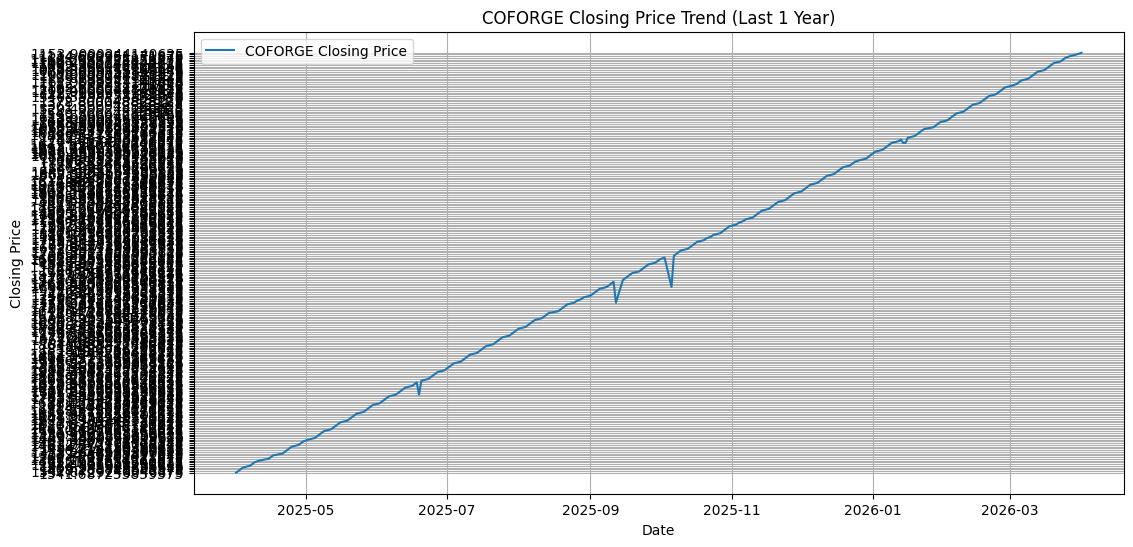

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], label="COFORGE Closing Price")
plt.title("COFORGE Closing Price Trend (Last 1 Year)")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid()
plt.show()

In [ ]:
print("Cleaned Time Series Data (ts.head()):")
display(ts.head())

In [ ]:
print("Data Types of Cleaned Time Series Data (ts.dtypes):")
display(ts.dtypes)

In [21]:
ts = df[['Date', 'Close']]
ts.head()

,Date,Close
1,2025-04-01,1541.687255859375
2,2025-04-02,1537.8729248046875
3,2025-04-03,1418.166748046875
4,2025-04-04,1309.288818359375
5,2025-04-07,1256.345947265625


In [22]:
ts.set_index('Date', inplace=True)

In [23]:
ts.head()

,Close
Date,
2025-04-01,1541.687255859375
2025-04-02,1537.8729248046875
2025-04-03,1418.166748046875
2025-04-04,1309.288818359375
2025-04-07,1256.345947265625


In [24]:
print(type(ts.index))

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


/tmp/ipykernel_19726/2509403692.py:11: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")


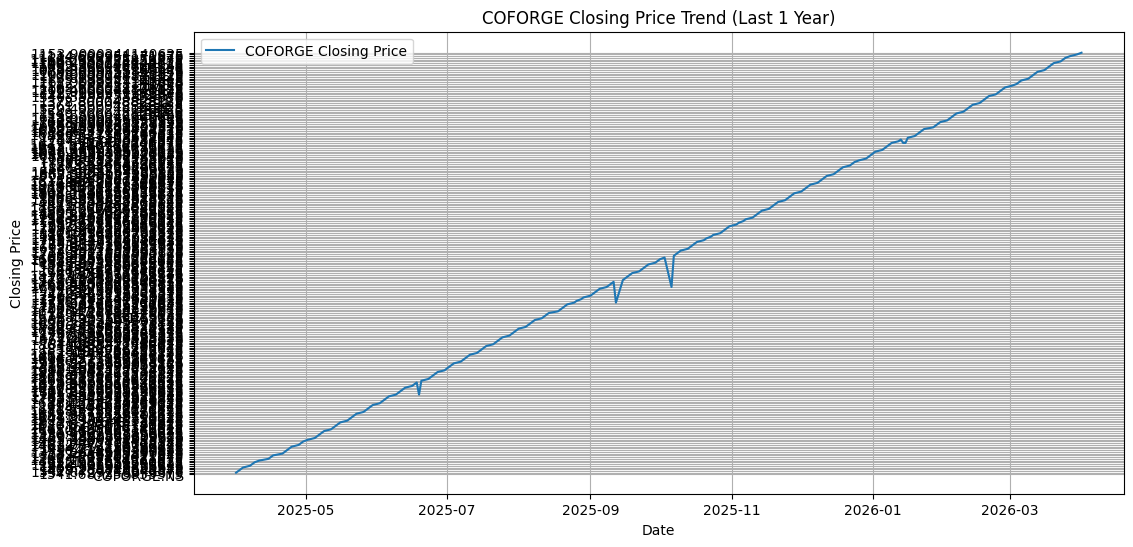

Time series data ready!


,Close
Date,
NaT,COFORGE.NS
2025-04-01,1541.687255859375
2025-04-02,1537.8729248046875
2025-04-03,1418.166748046875
2025-04-04,1309.288818359375


In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("COFORGE_1year.csv")

# Convert Date column to datetime, coercing errors to NaT
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Drop rows where 'Date' is NaT (this handles the problematic first row)
df.dropna(subset=['Date'], inplace=True)

# Convert 'Close' column to numeric, coercing errors to NaN
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

# Drop any remaining rows with NaN in 'Close' after conversion
df.dropna(subset=['Close'], inplace=True)

# Plot closing price trend
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], label="COFORGE Closing Price")
plt.title("COFORGE Closing Price Trend (Last 1 Year)")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid()
plt.show()

# Create time series dataset
ts = df[['Date', 'Close']]
ts.set_index('Date', inplace=True)

print("Time series data ready!")
ts.head()

In [27]:
from statsmodels.tsa.stattools import adfuller

In [28]:
ts.head()

,Close
Date,
NaT,COFORGE.NS
2025-04-01,1541.687255859375
2025-04-02,1537.8729248046875
2025-04-03,1418.166748046875
2025-04-04,1309.288818359375


In [31]:
ts.head()

,Close
Date,
NaT,COFORGE.NS
2025-04-01,1541.687255859375
2025-04-02,1537.8729248046875
2025-04-03,1418.166748046875
2025-04-04,1309.288818359375


In [32]:
ts.dtypes

,0
Close,object


In [36]:
df[df['Close'] == 'COFORGE.NS']

Price,Date,Close,High,Low,Open,Volume
Ticker,,COFORGE.NS,COFORGE.NS,COFORGE.NS,COFORGE.NS,COFORGE.NS
0,NaT,NaN,NaN,NaN,NaN,NaN
1,NaT,NaN,NaN,NaN,NaN,NaN
2,NaT,NaN,NaN,NaN,NaN,NaN
3,NaT,NaN,NaN,NaN,NaN,NaN
4,NaT,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
243,NaT,NaN,NaN,NaN,NaN,NaN
244,NaT,NaN,NaN,NaN,NaN,NaN
245,NaT,NaN,NaN,NaN,NaN,NaN


In [37]:
df.dtypes

,,0
Price,Ticker,
Date,,datetime64[ns]
Close,COFORGE.NS,float64
High,COFORGE.NS,float64
Low,COFORGE.NS,float64
Open,COFORGE.NS,float64
Volume,COFORGE.NS,int64


In [39]:
print(df.columns)

MultiIndex([(  'Date',           ''),
            ( 'Close', 'COFORGE.NS'),
            (  'High', 'COFORGE.NS'),
            (   'Low', 'COFORGE.NS'),
            (  'Open', 'COFORGE.NS'),
            ('Volume', 'COFORGE.NS')],
           names=['Price', 'Ticker'])


In [40]:
print(type(df['Close']))

<class 'pandas.core.frame.DataFrame'>


In [42]:
print(df.columns)

MultiIndex([(  'Date',           ''),
            ( 'Close', 'COFORGE.NS'),
            (  'High', 'COFORGE.NS'),
            (   'Low', 'COFORGE.NS'),
            (  'Open', 'COFORGE.NS'),
            ('Volume', 'COFORGE.NS')],
           names=['Price', 'Ticker'])


In [43]:
print(df.head())

Price        Date        Close         High          Low         Open  \
Ticker              COFORGE.NS   COFORGE.NS   COFORGE.NS   COFORGE.NS   
0      2025-04-01  1541.687256  1598.979375  1537.565911  1598.979375   
1      2025-04-02  1537.872925  1552.307364  1516.572884  1541.687094   
2      2025-04-03  1418.166748  1515.760582  1415.115437  1505.090728   
3      2025-04-04  1309.288818  1405.574982  1300.025801  1396.955822   
4      2025-04-07  1256.345947  1271.057814  1182.905373  1183.886156   

Price      Volume  
Ticker COFORGE.NS  
0         2221335  
1         2470850  
2         6409960  
3        11705110  
4        11740295  


In [44]:
print(df.head())

Price        Date        Close         High          Low         Open  \
Ticker              COFORGE.NS   COFORGE.NS   COFORGE.NS   COFORGE.NS   
0      2025-04-01  1541.687256  1598.979375  1537.565911  1598.979375   
1      2025-04-02  1537.872925  1552.307364  1516.572884  1541.687094   
2      2025-04-03  1418.166748  1515.760582  1415.115437  1505.090728   
3      2025-04-04  1309.288818  1405.574982  1300.025801  1396.955822   
4      2025-04-07  1256.345947  1271.057814  1182.905373  1183.886156   

Price      Volume  
Ticker COFORGE.NS  
0         2221335  
1         2470850  
2         6409960  
3        11705110  
4        11740295  


In [45]:
df.columns[df.columns == "Close"]

MultiIndex([], names=['Price', 'Ticker'])

In [47]:
print(df.columns)

MultiIndex([(  'Date',           ''),
            ( 'Close', 'COFORGE.NS'),
            (  'High', 'COFORGE.NS'),
            (   'Low', 'COFORGE.NS'),
            (  'Open', 'COFORGE.NS'),
            ('Volume', 'COFORGE.NS')],
           names=['Price', 'Ticker'])


In [48]:
df.columns = df.columns.get_level_values(0)

In [49]:
print(df.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


In [50]:
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
df = df.dropna(subset=['Close'])

In [51]:
import pandas as pd

# Fix MultiIndex columns
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

print("Fixed Columns:", df.columns)

# Convert Close column to numeric
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

# Drop rows where Close is NaN
df = df.dropna(subset=['Close'])

df.head()

Fixed Columns: Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


Price,Date,Close,High,Low,Open,Volume
0,2025-04-01,1541.687256,1598.979375,1537.565911,1598.979375,2221335
1,2025-04-02,1537.872925,1552.307364,1516.572884,1541.687094,2470850
2,2025-04-03,1418.166748,1515.760582,1415.115437,1505.090728,6409960
3,2025-04-04,1309.288818,1405.574982,1300.025801,1396.955822,11705110
4,2025-04-07,1256.345947,1271.057814,1182.905373,1183.886156,11740295


In [52]:
df['Date'] = pd.to_datetime(df['Date'])
ts = df[['Date', 'Close']]
ts.set_index('Date', inplace=True)

In [53]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts['Close'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -0.3442028391012586
p-value: 0.9190063833789388


In [54]:
ts_diff = ts['Close'].diff().dropna()
ts_diff.head()

,Close
Date,
2025-04-02,-3.814331
2025-04-03,-119.706177
2025-04-04,-108.877930
2025-04-07,-52.942871
2025-04-08,26.134644


In [55]:
from statsmodels.tsa.stattools import adfuller

result2 = adfuller(ts_diff)

print("ADF Statistic (After Differencing):", result2[0])
print("p-value (After Differencing):", result2[1])

ADF Statistic (After Differencing): -14.084866612318455
p-value (After Differencing): 2.7869661632868725e-26


<Figure size 1200x600 with 0 Axes>

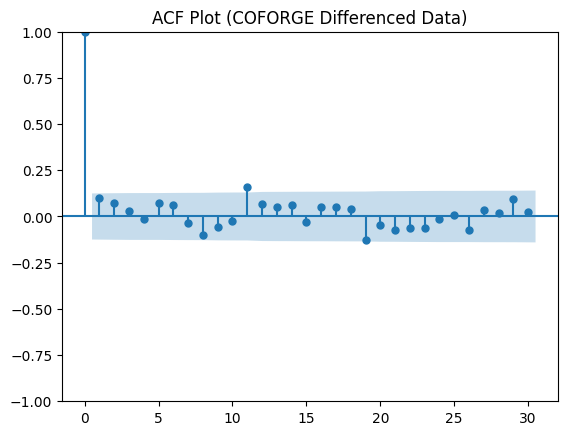

In [56]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plot_acf(ts_diff, lags=30)
plt.title("ACF Plot (COFORGE Differenced Data)")
plt.show()

<Figure size 1200x600 with 0 Axes>

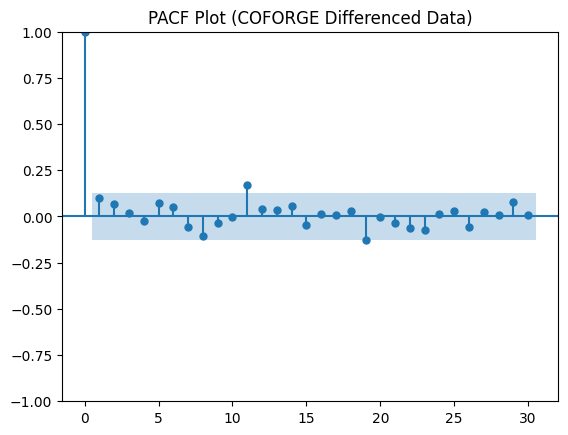

In [57]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(12,6))
plot_pacf(ts_diff, lags=30)
plt.title("PACF Plot (COFORGE Differenced Data)")
plt.show()

In [58]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(ts['Close'], order=(2,1,2))
model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  248
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -1230.469
Date:                Wed, 01 Apr 2026   AIC                           2470.938
Time:                        18:13:08   BIC                           2488.485
Sample:                             0   HQIC                          2478.003
                                - 248                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2939      0.397     -0.740      0.459      -1.072       0.485
ar.L2          0.6602      0.378      1.747      0.081      -0.080       1.401
ma.L1          0.4030      0.421      0.956      0.3

/tmp/ipykernel_19726/992725551.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ts['Fitted'] = model_fit.predict(start=0, end=len(ts)-1)


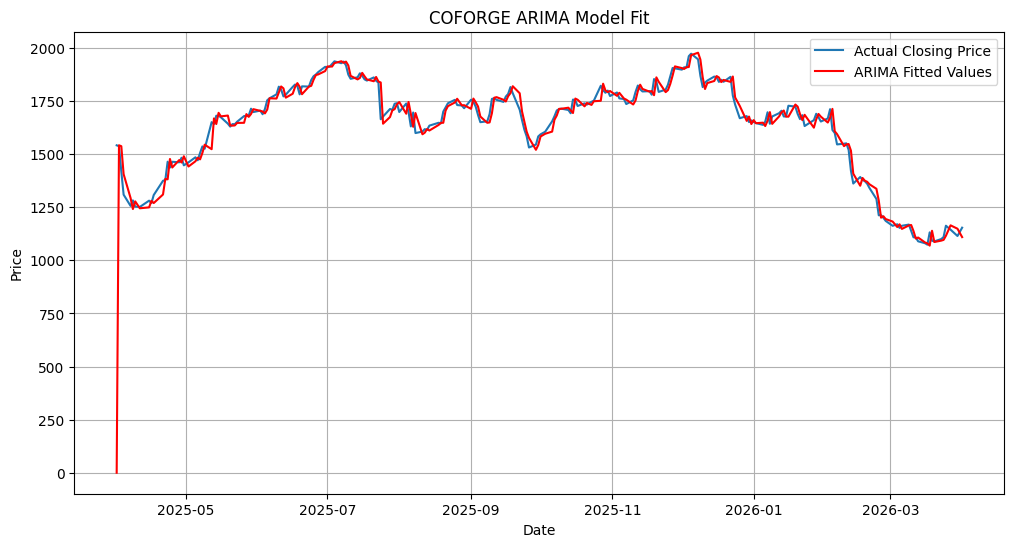

In [59]:
ts['Fitted'] = model_fit.predict(start=0, end=len(ts)-1)

plt.figure(figsize=(12,6))
plt.plot(ts['Close'], label="Actual Closing Price")
plt.plot(ts['Fitted'], label="ARIMA Fitted Values", color="red")
plt.title("COFORGE ARIMA Model Fit")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()

In [60]:
forecast_30 = model_fit.forecast(steps=30)
forecast_30

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


,predicted_mean
248,1160.652492
249,1158.357684
250,1163.490487
251,1160.466663
252,1164.744369
253,1161.490555
254,1165.271287
255,1162.011698
256,1165.466003
257,1162.298547


In [61]:
print("Last Close Price:", ts['Close'].iloc[-1])

Last Close Price: 1153.9000244140625


In [62]:
forecast_30 = model_fit.get_forecast(steps=30)
forecast_values = forecast_30.predicted_mean

forecast_values.index = pd.date_range(start=ts.index[-1] + pd.Timedelta(days=1), periods=30)

print(forecast_values.head())

2026-04-02    1160.652492
2026-04-03    1158.357684
2026-04-04    1163.490487
2026-04-05    1160.466663
2026-04-06    1164.744369
Freq: D, Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


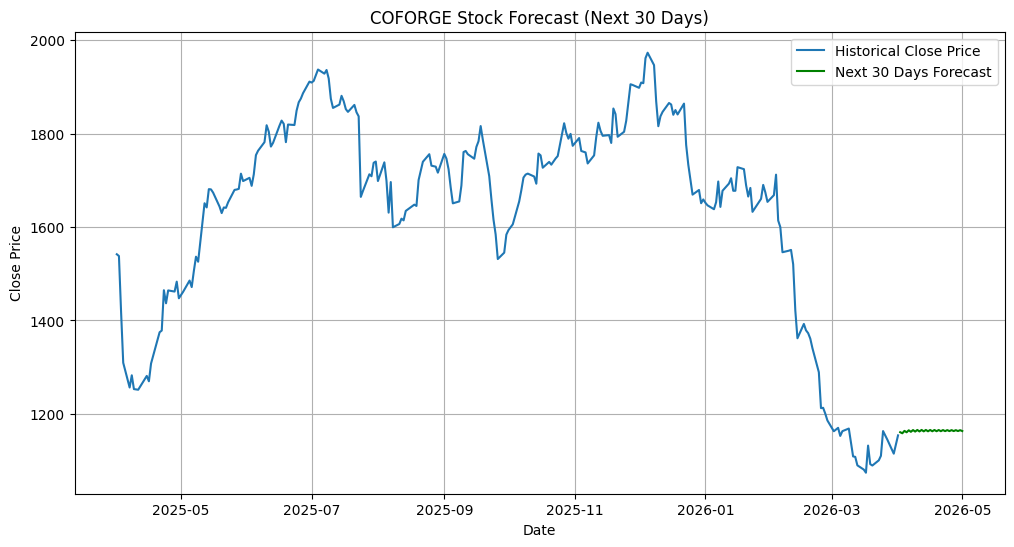

In [63]:
plt.figure(figsize=(12,6))
plt.plot(ts['Close'], label="Historical Close Price")
plt.plot(forecast_values, label="Next 30 Days Forecast", color="green")

plt.title("COFORGE Stock Forecast (Next 30 Days)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid()
plt.show()

In [65]:
forecast_obj = model_fit.get_forecast(steps=30)
forecast_mean = forecast_obj.predicted_mean

# Give future date index
forecast_mean.index = pd.date_range(start=ts.index[-1] + pd.Timedelta(days=1), periods=30)

print(forecast_mean)

2026-04-02    1160.652492
2026-04-03    1158.357684
2026-04-04    1163.490487
2026-04-05    1160.466663
2026-04-06    1164.744369
2026-04-07    1161.490555
2026-04-08    1165.271287
2026-04-09    1162.011698
2026-04-10    1165.466003
2026-04-11    1162.298547
2026-04-12    1165.510249
2026-04-13    1162.474933
2026-04-14    1165.487618
2026-04-15    1162.598044
2026-04-16    1165.436490
2026-04-17    1162.694355
2026-04-18    1165.374424
2026-04-19    1162.776187
2026-04-20    1165.309392
2026-04-21    1162.849331
2026-04-22    1165.244956
2026-04-23    1162.916564
2026-04-24    1165.182650
2026-04-25    1162.979268
2026-04-26    1165.123083
2026-04-27    1163.038176
2026-04-28    1165.066438
2026-04-29    1163.093720
2026-04-30    1165.012713
2026-05-01    1163.146184
Freq: D, Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [66]:
forecast_obj = model_fit.get_forecast(steps=30)
forecast_mean = forecast_obj.predicted_mean

forecast_mean.index = pd.date_range(
    start=ts.index[-1] + pd.Timedelta(days=1),
    periods=30
)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


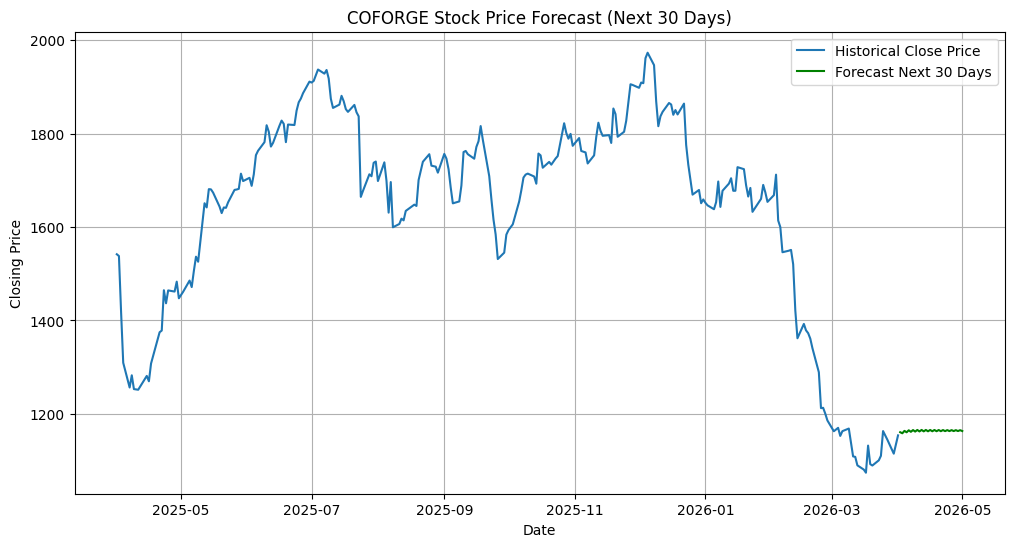

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(ts['Close'], label="Historical Close Price")
plt.plot(forecast_mean, label="Forecast Next 30 Days", color="green")

plt.title("COFORGE Stock Price Forecast (Next 30 Days)")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.legend()
plt.grid()
plt.show()

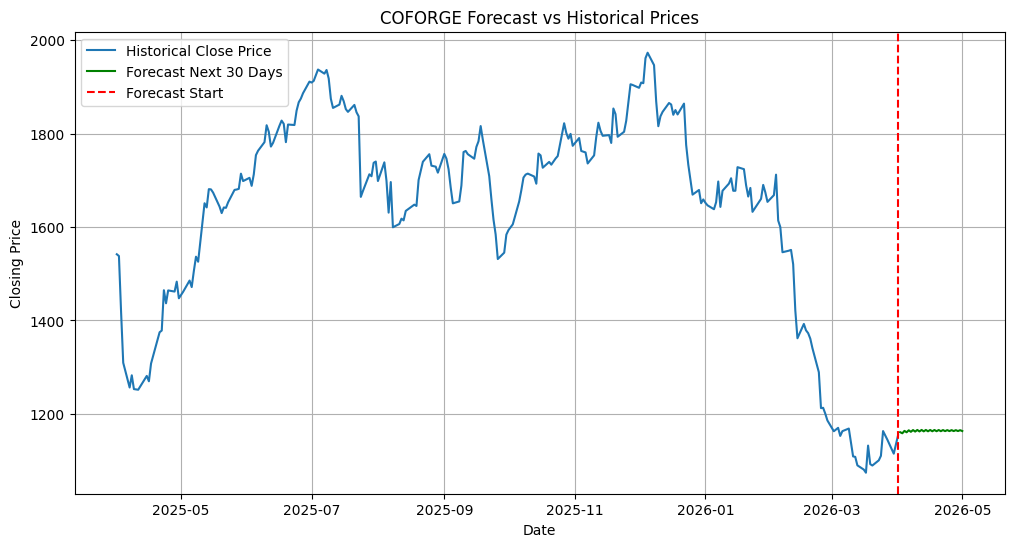

In [68]:
plt.figure(figsize=(12,6))

plt.plot(ts['Close'], label="Historical Close Price")
plt.plot(forecast_mean, label="Forecast Next 30 Days", color="green")

plt.axvline(ts.index[-1], color="red", linestyle="--", label="Forecast Start")

plt.title("COFORGE Forecast vs Historical Prices")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


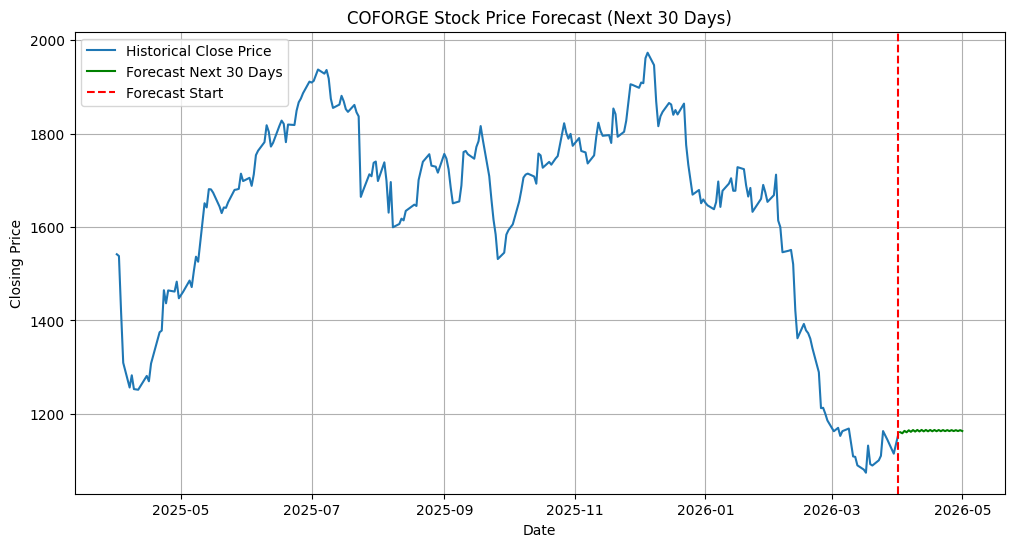

In [69]:
import matplotlib.pyplot as plt
import pandas as pd

# Get forecast for 30 days
forecast_obj = model_fit.get_forecast(steps=30)
forecast_mean = forecast_obj.predicted_mean

# Create future date index
forecast_mean.index = pd.date_range(
    start=ts.index[-1] + pd.Timedelta(days=1),
    periods=30
)

# Plot historical + forecast
plt.figure(figsize=(12,6))

plt.plot(ts['Close'], label="Historical Close Price")
plt.plot(forecast_mean, label="Forecast Next 30 Days", color="green")

plt.axvline(ts.index[-1], color="red", linestyle="--", label="Forecast Start")

plt.title("COFORGE Stock Price Forecast (Next 30 Days)")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid()

plt.savefig("COFORGE_forecast_graph.png")  # save image
plt.show()

In [70]:
last_price = ts['Close'].iloc[-1]
print("Last Closing Price:", last_price)

Last Closing Price: 1153.9000244140625


In [71]:
future_avg = forecast_mean.mean()
print("Average Forecast Price:", future_avg)

Average Forecast Price: 1163.5188185785316


In [72]:
if future_avg > last_price:
    print("Upward Trend")
elif future_avg < last_price:
    print("Downward Trend")
else:
    print("Stable Trend")

Upward Trend


In [74]:
import pandas as pd

# Get forecast for next 30 days
forecast_obj = model_fit.get_forecast(steps=30)
forecast_mean = forecast_obj.predicted_mean

# Give proper future dates
forecast_mean.index = pd.date_range(
    start=ts.index[-1] + pd.Timedelta(days=1),
    periods=30
)

# Convert forecast into DataFrame
forecast_df = pd.DataFrame(forecast_mean, columns=["Forecast"])

# Save to CSV
forecast_df.to_csv("COFORGE_forecast_30days.csv")

print("Forecast CSV saved successfully!")

Forecast CSV saved successfully!


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
